---
numbering: false
---

# 1.5: Length and distance

In [Chapter 1.4](01-04.ipynb), we learned how to add and scale vectors. Now, let's look more closely at their geometry. How long is a vector? And how can we use vectors to find the distance between two points?

## Length of a vector

Start with the vector

$$\vec v = \begin{bmatrix} 3 \\ 4 \end{bmatrix}.$$

To draw $\vec v$ from the origin, we move 3 units to the right and 4 units up. The resulting arrow is the hypotenuse of a right triangle. By the **Pythagorean theorem**, its length is

$$\sqrt{3^2 + 4^2} = \sqrt{25} = 5.$$

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path as _PlotPath
import sys as _plot_sys

_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly


def _vector_figure(vectors, vdeltax=0.3, vdeltay=0.3, vdeltaz=0.3):
    dimension = len(vectors[0][0][0])
    fig = go.Figure()

    for (start, end), color, label in vectors:
        start = np.asarray(start, dtype=float)
        end = np.asarray(end, dtype=float)
        delta = end - start

        if dimension == 2:
            fig.add_trace(go.Scatter(
                x=[start[0], end[0]], y=[start[1], end[1]], mode="lines",
                line=dict(color=color, width=4), showlegend=False,
                hovertemplate="(%{x}, %{y})<extra></extra>",
            ))
            fig.add_annotation(
                x=end[0], y=end[1], ax=start[0], ay=start[1],
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=3,
                arrowcolor=color,
            )
            if label:
                midpoint = (start + end) / 2
                fig.add_annotation(
                    x=midpoint[0] + vdeltax, y=midpoint[1] + vdeltay,
                    text=label, showarrow=False, font=dict(color=color, size=16),
                )
        else:
            fig.add_trace(go.Scatter3d(
                x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
                mode="lines", line=dict(color=color, width=8),
                showlegend=False, hoverinfo="skip",
            ))
            length = np.linalg.norm(delta)
            if length:
                unit = delta / length
                fig.add_trace(go.Cone(
                    x=[end[0]], y=[end[1]], z=[end[2]],
                    u=[unit[0]], v=[unit[1]], w=[unit[2]],
                    anchor="tip", sizemode="absolute", sizeref=0.28,
                    colorscale=[[0, color], [1, color]], showscale=False,
                    hoverinfo="skip",
                ))
            if label:
                midpoint = (start + end) / 2
                fig.add_trace(go.Scatter3d(
                    x=[midpoint[0] + vdeltax], y=[midpoint[1] + vdeltay],
                    z=[midpoint[2] + vdeltaz], mode="text", text=[label],
                    textfont=dict(color=color, size=16), hoverinfo="skip",
                    showlegend=False,
                ))

    return fig


def plot_vectors_non_origin(vectors, **kwargs):
    return _vector_figure(vectors, **kwargs)


def plot_vectors(vectors, **kwargs):
    converted = []
    for endpoint, color, label in vectors:
        converted.append(((tuple(0 for _ in endpoint), endpoint), color, label))
    return _vector_figure(converted, **kwargs)


def _set_vector_colors(fig, vectors, overrides):
    if np.asarray(vectors[0][0]).ndim == 1:
        vectors = [((tuple(0 for _ in endpoint), endpoint), color, label) for endpoint, color, label in vectors]
    dimension = len(vectors[0][0][0])
    trace_index = 0
    annotation_index = 0

    for vector_index, ((start, end), _, label) in enumerate(vectors):
        color = overrides.get(vector_index)
        if dimension == 2:
            if color:
                fig.data[trace_index].line.color = color
                fig.layout.annotations[annotation_index].arrowcolor = color
                if label:
                    fig.layout.annotations[annotation_index + 1].font.color = color
            trace_index += 1
            annotation_index += 1 + bool(label)
        else:
            if color:
                fig.data[trace_index].line.color = color
            trace_index += 1
            if np.linalg.norm(np.asarray(end) - np.asarray(start)):
                if color:
                    fig.data[trace_index].colorscale = [[0, color], [1, color]]
                trace_index += 1
            if label:
                if color:
                    fig.data[trace_index].textfont.color = color
                trace_index += 1

    return fig


def finish_vectors(fig, vectors, renderer="png"):
    _style_plotly(fig, renderer=renderer)
    _set_vector_colors(fig, vectors, {i: item[1] for i, item in enumerate(vectors)})
    return fig

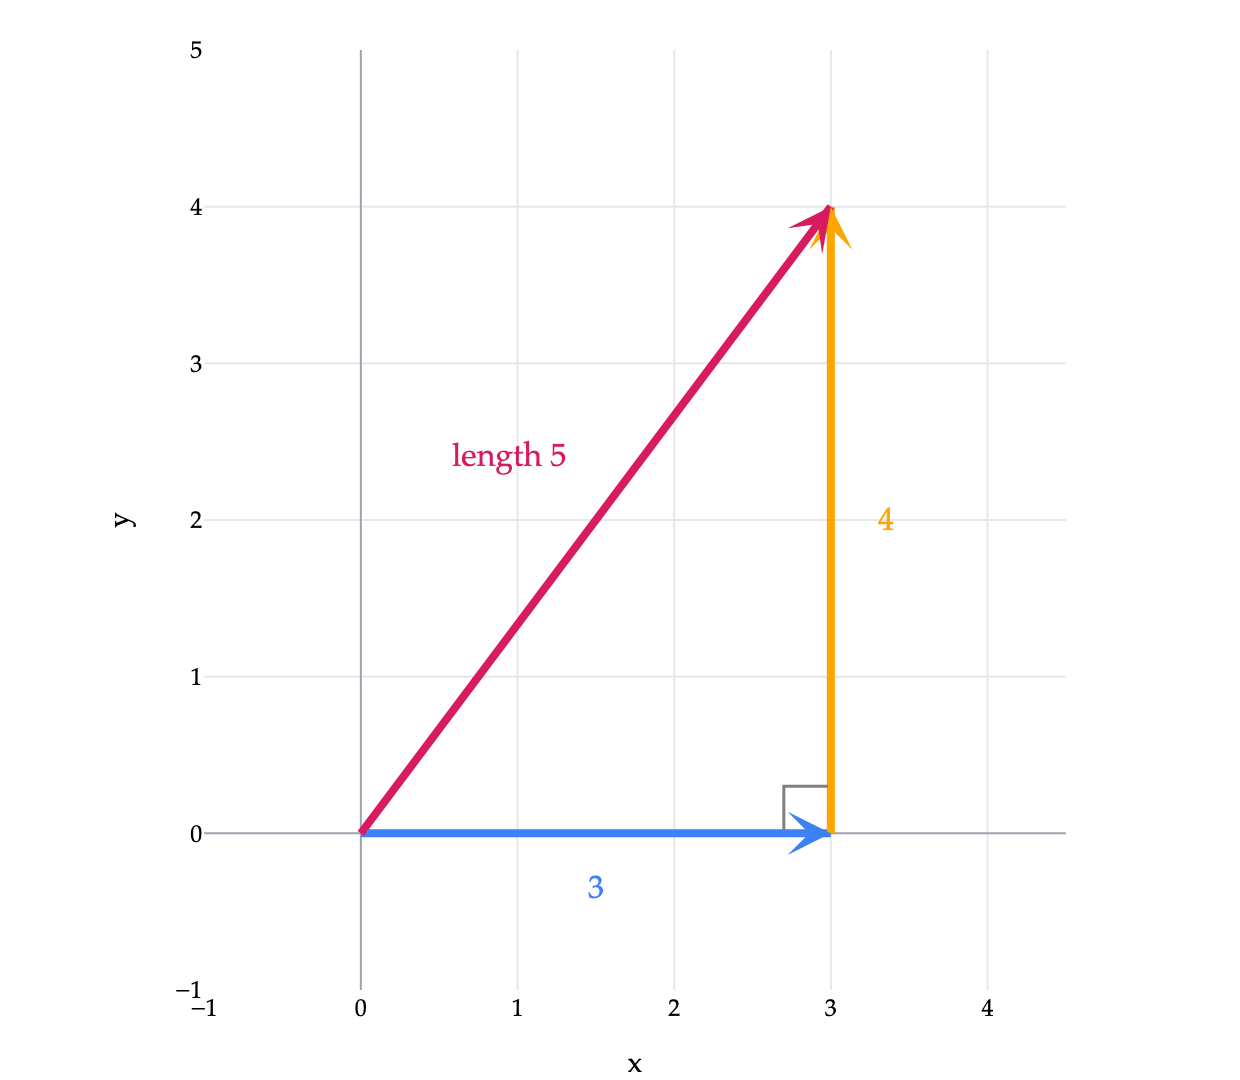

In [2]:
vectors = [
    (((0, 0), (3, 0)), '#3d81f6', '3'),
    (((3, 0), (3, 4)), 'orange', '4'),
    (((0, 0), (3, 4)), '#d81a60', 'length 5'),
]
fig = plot_vectors_non_origin(vectors)
fig.layout.annotations[1].update(x=1.5, y=-0.35)
fig.layout.annotations[3].update(x=3.35, y=2)
fig.layout.annotations[5].update(x=0.95, y=2.4)
fig.add_shape(type='path', path='M 2.7,0 L 2.7,0.3 L 3,0.3', line=dict(color='gray', width=1.5))
fig.update_layout(width=620, height=540, xaxis_title='x', yaxis_title='y', margin=dict(l=45,r=30,t=25,b=45))
fig.update_xaxes(range=[-1, 4.5], dtick=1, constrain='domain')
fig.update_yaxes(range=[-1, 5], dtick=1, scaleanchor='x', scaleratio=1)
finish_vectors(fig, vectors)
fig.show(scale=2)

We use **norm** as another word for length, and write the norm of $\vec v$ as $\lVert \vec v \rVert$. Here, $\lVert \vec v \rVert = 5$.

### Length in three dimensions

What if we add a third component? Consider

$$\vec v = \begin{bmatrix} 3 \\ 4 \\ 5 \end{bmatrix}.$$

We can find its length by applying the Pythagorean theorem **twice**. First, move 3 units in the $x$ direction and 4 units in the $y$ direction. The blue diagonal in the $xy$-plane has length

$$\sqrt{3^2 + 4^2} = 5.$$

Then, move 5 units upward. This vertical segment is perpendicular to the $xy$-plane, so we get another right triangle. Its legs both have length 5, and its hypotenuse is our original vector. Therefore,

$$\lVert \vec v \rVert = \sqrt{5^2 + 5^2} = \sqrt{50} = 5\sqrt{2}.$$

Drag the figure below to see the two right triangles from different viewpoints.

In [3]:
vectors = [
    (((0, 0, 0), (3, 0, 0)), 'gray', '3'),
    (((3, 0, 0), (3, 4, 0)), 'gray', '4'),
    (((0, 0, 0), (3, 4, 0)), '#3d81f6', 'length 5'),
    (((3, 4, 0), (3, 4, 5)), 'orange', 'length 5'),
    (((0, 0, 0), (3, 4, 5)), '#d81a60', 'length √50'),
]
fig = plot_vectors_non_origin(vectors, vdeltax=0.15, vdeltay=0.15, vdeltaz=0.2)
fig.update_layout(width=590, height=520, margin=dict(l=0,r=0,t=15,b=0),
    scene=dict(xaxis=dict(title='x',range=[-0.5,4],dtick=1),
               yaxis=dict(title='y',range=[-0.5,5],dtick=1),
               zaxis=dict(title='z',range=[-0.5,6],dtick=1),
               aspectmode='data', camera=dict(eye=dict(x=1.6,y=-1.8,z=1.1))))
fig.data[14].update(x=[1.1], y=[2.0], z=[3.3])
finish_vectors(fig, vectors, renderer='plotly_mimetype')
fig.show()

Notice that this is the same as taking the square root of the sum of the squares of all three components:

$$\lVert \vec v \rVert = \sqrt{3^2 + 4^2 + 5^2}.$$

### The definition

The same pattern gives us a definition for any number of components.

:::{note} Definition: Length of a vector
For a vector $\vec v = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix} \in \mathbb{R}^n$, its **length**, or **norm**, is

$$\boxed{\lVert \vec v \rVert = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}.}$$
:::

Square each component, add the squares, and take the square root. For instance,

$$\left\lVert \begin{bmatrix} -1 \\ 2 \\ 0 \\ -2 \end{bmatrix} \right\rVert
= \sqrt{(-1)^2 + 2^2 + 0^2 + (-2)^2} = \sqrt{9} = 3.$$

This vector has **four components**, but its **length is 3**. Those are different quantities!

---

## Lengths of linear combinations

What happens to a vector's length when we scale it? If $\vec v$ has length 5, then $2\vec v$ has length 10. So does $-2\vec v$: the minus sign reverses the direction, but the arrow is still twice as long.

:::{note} Properties of length
For any vector $\vec v$ and any scalar $c$:

- $\lVert \vec v \rVert \geq 0$. Lengths cannot be negative.
- $\lVert \vec v \rVert = 0$ exactly when $\vec v = \vec 0$.
- $\boxed{\lVert c\vec v \rVert = |c|\lVert \vec v \rVert}$. Scaling by $c$ multiplies the length by $|c|$.
:::

To find the length of a linear combination such as $2\vec u - \vec v$, **compute the vector first**, then take its norm.

::::{tip} Activity 1
Let

$$\vec u = \begin{bmatrix} 3 \\ 4 \end{bmatrix}, \qquad
\vec v = \begin{bmatrix} 1 \\ -2 \end{bmatrix}.$$

1. Find $\lVert \vec u \rVert$ and $\lVert \vec v \rVert$.
2. Find $\lVert \vec u + \vec v \rVert$.
3. Find $\lVert 2\vec u - \vec v \rVert$.
4. Find $\lVert -3\vec v \rVert$ in two ways: by computing $-3\vec v$ first, and by using the scaling property.
5. Is $\lVert \vec u + \vec v \rVert$ equal to $\lVert \vec u \rVert + \lVert \vec v \rVert$?

:::{tip} Solution
:class: dropdown

1. $\lVert \vec u \rVert = 5$ and $\lVert \vec v \rVert = \sqrt{1+4} = \sqrt{5}$.
2. $\vec u + \vec v = \begin{bmatrix} 4 \\ 2 \end{bmatrix}$, so $\lVert \vec u + \vec v \rVert = \sqrt{16+4} = 2\sqrt{5}$.
3. $2\vec u - \vec v = \begin{bmatrix} 6-1 \\ 8-(-2) \end{bmatrix} = \begin{bmatrix} 5 \\ 10 \end{bmatrix}$, so its norm is $\sqrt{25+100} = 5\sqrt{5}$.
4. $-3\vec v = \begin{bmatrix} -3 \\ 6 \end{bmatrix}$, whose norm is $\sqrt{9+36} = 3\sqrt{5}$. The scaling property gives the same answer: $|-3|\lVert \vec v \rVert = 3\sqrt{5}$.
5. No: $2\sqrt{5} \neq 5+\sqrt{5}$. Adding vectors does not usually add their lengths.
:::
::::

### The triangle inequality

Imagine traveling from $A$ to $B$, then from $B$ to $C$. Let $\vec u$ and $\vec v$ represent those two displacements. The direct displacement from $A$ to $C$ is $\vec u + \vec v$.

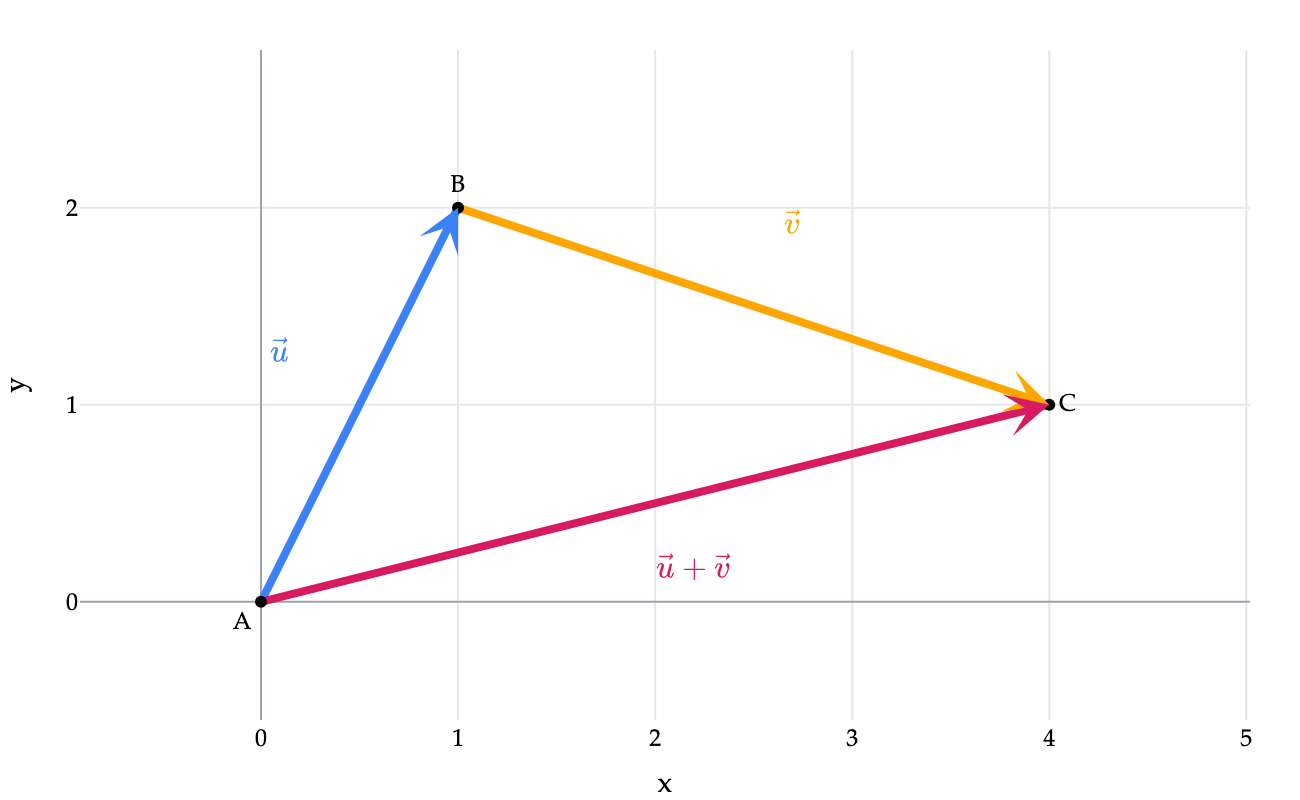

In [4]:
vectors = [
    (((0, 0), (1, 2)), '#3d81f6', r'$\vec u$'),
    (((1, 2), (4, 1)), 'orange', r'$\vec v$'),
    (((0, 0), (4, 1)), '#d81a60', r'$\vec u + \vec v$'),
]
fig = plot_vectors_non_origin(vectors)
fig.layout.annotations[1].update(x=0.1, y=1.3)
fig.layout.annotations[3].update(x=2.7, y=1.95)
fig.layout.annotations[5].update(x=2.2, y=0.2)
fig.update_layout(width=650, height=400, xaxis_title='x', yaxis_title='y', margin=dict(l=40,r=25,t=25,b=40))
fig.update_xaxes(range=[-0.7, 4.8], dtick=1)
fig.update_yaxes(range=[-0.6, 2.8], dtick=1, scaleanchor='x', scaleratio=1)
finish_vectors(fig, vectors)
fig.add_trace(go.Scatter(x=[0,1,4],y=[0,2,1],mode='markers+text',text=['A','B','C'],
    textposition=['bottom left','top center','middle right'],marker=dict(color='black',size=6),showlegend=False))
fig.show(scale=2)

The straight path cannot be longer than the path through $B$. In terms of lengths:

:::{note} Triangle inequality
For vectors $\vec u$ and $\vec v$ with the same number of components,

$$\boxed{\lVert \vec u + \vec v \rVert \leq \lVert \vec u \rVert + \lVert \vec v \rVert.}$$
:::

The two sides can be equal. For example, if we travel 3 meters east and then another 4 meters east, our total displacement has length 7 meters. But if we change direction along the way, the direct route is shorter.

### Unit vectors

Sometimes we want to describe a direction without specifying how far to travel in that direction. A **unit vector** is a vector with length 1. To turn a nonzero vector into a unit vector pointing in the same direction, divide it by its length:

$$\boxed{\frac{\vec v}{\lVert \vec v \rVert}.}$$

For example, $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$ has length 5, so $\begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix}$ is a unit vector in the same direction. We call this process **normalizing** a vector. We cannot normalize $\vec 0$, since its length is 0.

::::{tip} Activity 2
Find a unit vector in the direction of $\vec w = \begin{bmatrix} 0 \\ 3 \\ -4 \end{bmatrix}$. Then find a vector of length 10 in that direction.

:::{tip} Solution
:class: dropdown

Since $\lVert \vec w \rVert = 5$, the unit vector is $\begin{bmatrix} 0 \\ 3/5 \\ -4/5 \end{bmatrix}$. Multiplying it by 10 gives $\begin{bmatrix} 0 \\ 6 \\ -8 \end{bmatrix}$, which has length 10 and points in the same direction.
:::
::::

---

## Distance between points

Length measures how far an arrow travels. To find the distance between two points, we just need the arrow connecting them!

Suppose $A$ and $B$ have position vectors $\vec a$ and $\vec b$. The displacement **from $B$ to $A$** is $\vec a-\vec b$, so the distance between the points is $\lVert \vec a-\vec b \rVert$.

:::{note} Definition: Distance between points
For points $A=(a_1,\ldots,a_n)$ and $B=(b_1,\ldots,b_n)$ with position vectors $\vec a$ and $\vec b$, their **distance** is

$$\boxed{d(A,B)=\lVert \vec a-\vec b \rVert
=\sqrt{(a_1-b_1)^2+\cdots+(a_n-b_n)^2}.}$$
:::

Subtract corresponding coordinates, then take the norm. Reversing the subtraction gives the opposite displacement, but the same distance: $\lVert \vec a-\vec b \rVert=\lVert \vec b-\vec a \rVert$.

### Example: A robot on a factory floor

A robot is at $B=(1,-1)$ and needs to reach a station at $A=(4,3)$. Both coordinates are measured in meters. Its displacement to the station is

$$\vec a-\vec b = \begin{bmatrix}4-1\\3-(-1)\end{bmatrix}
=\begin{bmatrix}3\\4\end{bmatrix}.$$

Therefore, the straight-line distance to the station is

$$d(A,B)=\sqrt{3^2+4^2}=\boxed{5\text{ meters}}.$$

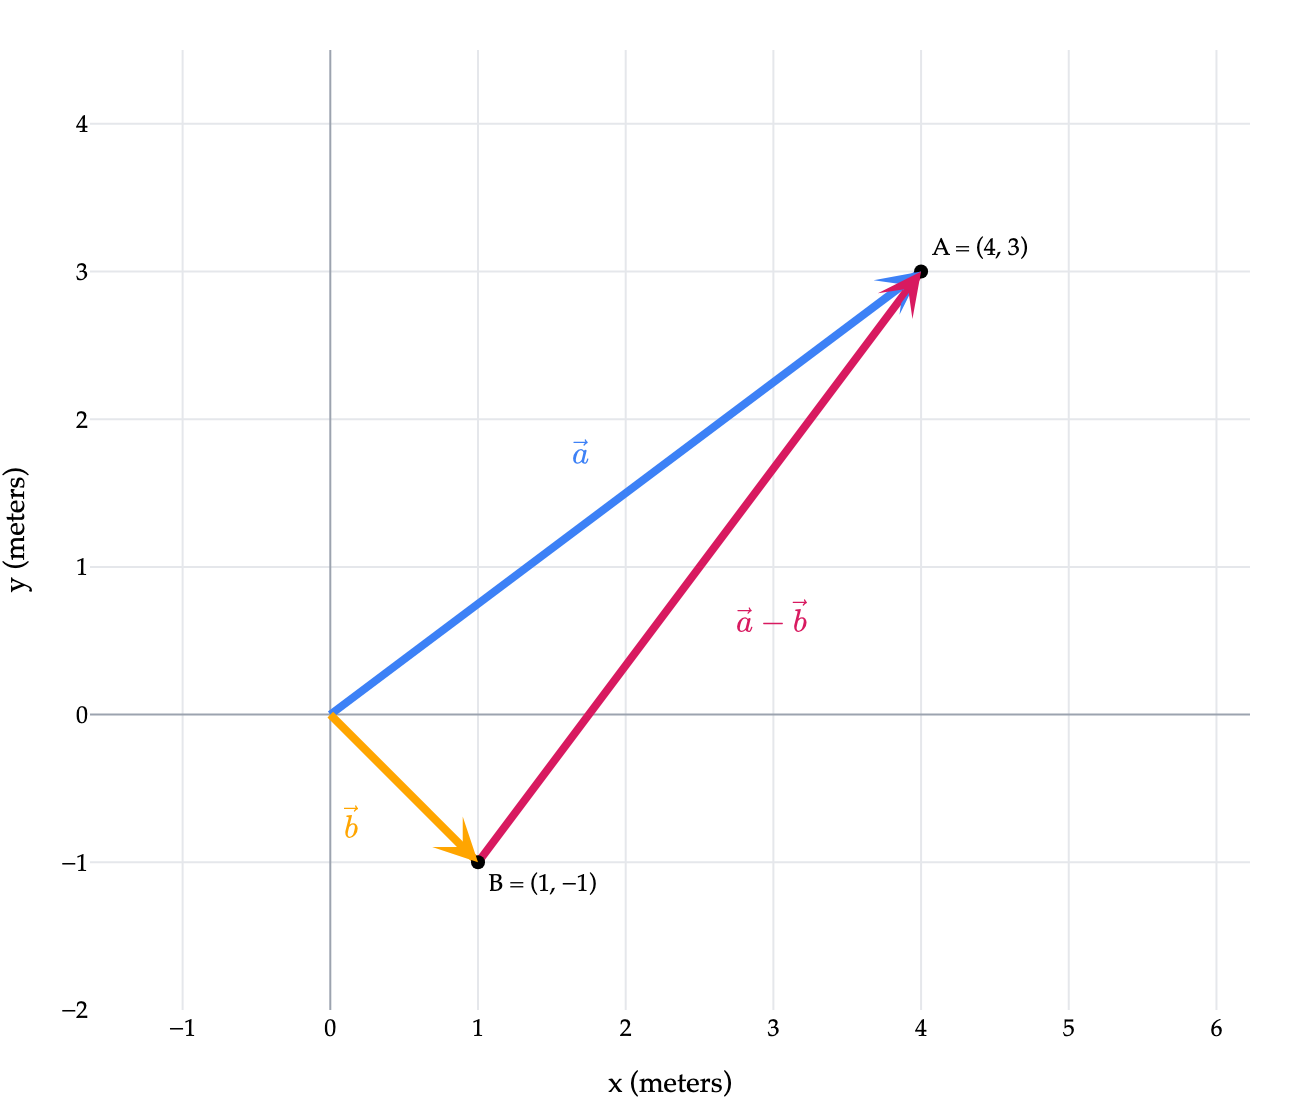

In [5]:
vectors = [
    (((0, 0), (4, 3)), '#3d81f6', r'$\vec a$'),
    (((0, 0), (1, -1)), 'orange', r'$\vec b$'),
    (((1, -1), (4, 3)), '#d81a60', r'$\vec a - \vec b$'),
]
fig = plot_vectors_non_origin(vectors)
fig.layout.annotations[1].update(x=1.7, y=1.8)
fig.layout.annotations[3].update(x=0.15, y=-0.7)
fig.layout.annotations[5].update(x=3, y=0.7)
fig.update_layout(width=650,height=550,xaxis_title='x (meters)',yaxis_title='y (meters)',margin=dict(l=45,r=25,t=25,b=45))
fig.update_xaxes(range=[-1,5.6],dtick=1)
fig.update_yaxes(range=[-2,4.5],dtick=1,scaleanchor='x',scaleratio=1)
finish_vectors(fig,vectors)
fig.add_trace(go.Scatter(x=[4,1],y=[3,-1],mode='markers+text',text=['A = (4, 3)','B = (1, −1)'],
    textposition=['top right','bottom right'],textfont=dict(color='black'),marker=dict(color='black',size=7),showlegend=False))
fig.show(scale=2)

If the robot must travel around a machine, its actual route may be longer. The norm gives the **straight-line distance** between the endpoints.

### Example: A support cable

A straight, taut cable connects a ground anchor at $P=(1,-1,0)$ to a point on a tower at $Q=(4,3,5)$. Coordinates are measured in meters, with $z$ measuring height above the ground.

The displacement from the anchor to the tower attachment is

$$\begin{bmatrix}4-1\\3-(-1)\\5-0\end{bmatrix}
=\begin{bmatrix}3\\4\\5\end{bmatrix}.$$

The cable's length is therefore

$$\sqrt{3^2+4^2+5^2}=\boxed{5\sqrt{2}\text{ meters}}\approx 7.07\text{ meters}.$$

This is the same geometry as our earlier three-dimensional example, translated to start at the ground anchor.

::::{tip} Activity 3
A robot arm should place a part at $T=(4,3,2)$, but a sensor reports that it placed the part at $P=(4.03,2.96,2.12)$. All coordinates are in meters.

1. Find the displacement from the target position to the actual position.
2. Find the distance between the target and actual positions.
3. The part must be placed within 0.10 meters of the target. Does this placement meet the requirement?

:::{tip} Solution
:class: dropdown

1. The displacement is $\begin{bmatrix}0.03\\-0.04\\0.12\end{bmatrix}$ meters.
2. The distance is $\sqrt{0.03^2+(-0.04)^2+0.12^2}=\sqrt{0.0169}=0.13$ meters.
3. No: $0.13>0.10$. Each coordinate alone does not tell us the full distance from the target; we need the norm of the displacement.
:::
::::

In [Chapter 1.6](01-06.ipynb), we'll use vector lengths to help measure **angles** between vectors.